# Quantitative analysis of simulations for different grid structures

### helper

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [87]:
grids = {
    "3by3": [],
    "5by5": [],
    "dense_limit": [],
    "dense": []
}

directory = "./data_80/"
pattern = re.compile(r"grid_(3by3|5by5|dense_limit|dense)_r\d+\.txt")

if os.path.exists(directory):
    for filename in os.listdir(directory):
        match = pattern.search(filename)
        if match:
            grid_type = match.group(1)
            full_path = os.path.join(directory, filename)
            grids[grid_type].append(full_path)

smallgrid = sorted(grids["3by3"])
mediumgrid = sorted(grids["5by5"])
densegrid = sorted(grids["dense_limit"])
closedgrid = sorted(grids["dense"])

In [ ]:
def load_file(path):
    df = pd.read_csv(path, sep=None, header=None, engine='python')
    df.columns = ['timesteps', 'cellid', 'cellkind', 'centroid_x', 'centroid_y']
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    df[['timesteps', 'cellid', 'cellkind']] = df[['timesteps', 'cellid', 'cellkind']].astype(int)
    return df.sort_values(['cellid', 'timesteps']).reset_index(drop=True)

def active(df):
    active = df[df['cellkind'] == 1].copy()
    active = active.sort_values(['cellid', 'timesteps'])
    return active.reset_index(drop=True)

def velocity(df):
    df['dx'] = df.groupby('cellid')['centroid_x'].diff()
    df['dy'] = df.groupby('cellid')['centroid_y'].diff()
    df['speed'] = np.sqrt(df['dx']**2 + df['dy']**2)
    df['unitvec_x'] = df['dx'] / df['speed']
    df['unitvec_y'] = df['dy'] / df['speed']
    return df.dropna()

def angle(df):
    df['prev_unitvec_x'] = df.groupby('cellid')['unitvec_x'].shift(1)
    df['prev_unitvec_y'] = df.groupby('cellid')['unitvec_y'].shift(1)
    dot_product = (df['unitvec_x'] * df['prev_unitvec_x']) + (df['unitvec_y'] * df['prev_unitvec_y'])
    df['turning_angle'] = np.arccos(np.clip(dot_product, -1.0, 1.0))
    return df

def prepare_data(path):
    df = load_file(path)
    df = active(df)
    df = velocity(df)
    df = angle(df)
    return df

def prepare_multiple_runs(paths):
    dfs = []
    for i, path in enumerate(paths):
        df = prepare_data(path)
        df['unique_id'] = f"{i}_" + df['cellid'].astype(str)
        dfs.append(df)
        
    return pd.concat(dfs, ignore_index=True)

In [ ]:
def plot_analysis(data_dict):
    sns.set_context("notebook", font_scale=1.2)
    sns.set_style("ticks")
    _, axes = plt.subplots(1, 2, figsize=(20, 6))
    colors = {"3x3": "#440154", "5x5": "#31688e", "Dense": "#35b779", "Caged": "#8fd744"}

    # Log-Scaled Speed Distribution
    for name, df in data_dict.items():
        valid_speeds = df[df['speed'] > 1e-5]['speed']
        sns.kdeplot(valid_speeds, ax=axes[0], label=name, fill=True, log_scale=True, color=colors[name], alpha=0.3)
    axes[0].set_title("Velocity Scales (Log)")
    axes[0].set_xlabel("Speed (Log)")
    axes[0].legend()

    # Reorientation Distribution 
    for name, df in data_dict.items():
        sns.kdeplot(np.degrees(df['turning_angle'].dropna()), ax=axes[1], label=name, fill=True, color=colors[name], alpha=0.3)
    axes[1].set_title("Turning Angle Distribution")
    axes[1].set_xlabel("Degrees")
    axes[1].set_xlim(0, 180)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 3x3

In [91]:
# OBSTACLE_SPACING = 75
# OBSTACLE_MARGIN  = 20
data_3x3 = prepare_multiple_runs(smallgrid)
data_3x3.head()

,timesteps,cellid,cellkind,centroid_x,centroid_y,dx,dy,speed,unitvec_x,unitvec_y,prev_unitvec_x,prev_unitvec_y,turning_angle,unique_id
0,3,10,1,28.000000,178.666667,0.500000,0.166667,0.527046,0.948683,0.316228,NaN,NaN,NaN,0_10
1,4,10,1,27.142857,178.285714,-0.857143,-0.380952,0.937986,-0.913812,-0.406138,0.948683,0.316228,3.045119,0_10
2,5,10,1,26.583333,178.666667,-0.559524,0.380952,0.676899,-0.826599,0.562791,-0.913812,-0.406138,1.015983,0_10
3,6,10,1,27.333333,178.111111,0.750000,-0.555556,0.933350,0.803557,-0.595228,-0.826599,0.562791,3.101802,0_10
4,7,10,1,27.461538,177.884615,0.128205,-0.226496,0.260263,0.492598,-0.870257,0.803557,-0.595228,0.418175,0_10


In [92]:
velocity_stats = data_3x3['speed'].agg(['mean', 'std'])
angle_stats = data_3x3['turning_angle'].dropna().agg(['mean', 'std'])

print(f"Velocity: {velocity_stats['mean']:.3f} ± {velocity_stats['std']:.3f}")
print(f"Turning Angle: {angle_stats['mean']:.3f} ± {angle_stats['std']:.3f}")

Velocity: 0.166 ± 2.692
Turning Angle: 0.938 ± 0.817


In [93]:
alignment_ts = data_3x3.groupby('timesteps').apply(
    lambda x: (x['unitvec_x'].sum()**2 + x['unitvec_y'].sum()**2)**0.5 / len(x)
)
mean_alignment = alignment_ts.mean()
print(mean_alignment)

0.06426269551468008


### 5x5

In [94]:
# OBSTACLE_SPACING = 40
# OBSTACLE_MARGIN  = 5
data_5x5 = prepare_multiple_runs(mediumgrid)
data_5x5.head()

,timesteps,cellid,cellkind,centroid_x,centroid_y,dx,dy,speed,unitvec_x,unitvec_y,prev_unitvec_x,prev_unitvec_y,turning_angle,unique_id
0,1,26,1,17.285714,182.500000,0.785714,-0.833333,1.145335,0.686013,-0.727589,NaN,NaN,NaN,0_26
1,2,26,1,17.440000,182.560000,0.154286,0.060000,0.165542,0.932005,0.362446,0.686013,-0.727589,1.185693,0_26
2,3,26,1,17.800000,182.650000,0.360000,0.090000,0.371080,0.970143,0.242536,0.932005,0.362446,0.125913,0_26
3,4,26,1,18.500000,182.576923,0.700000,-0.073077,0.703804,0.994595,-0.103831,0.970143,0.242536,0.348997,0_26
4,5,26,1,18.621212,182.712121,0.121212,0.135198,0.181579,0.667545,0.744569,0.994595,-0.103831,0.943908,0_26


In [95]:
velocity_stats = data_5x5['speed'].agg(['mean', 'std'])
angle_stats = data_5x5['turning_angle'].dropna().agg(['mean', 'std'])

print(f"Velocity: {velocity_stats['mean']:.3f} ± {velocity_stats['std']:.3f}")
print(f"Turning Angle: {angle_stats['mean']:.3f} ± {angle_stats['std']:.3f}")

Velocity: 0.156 ± 2.773
Turning Angle: 0.971 ± 0.846


In [96]:
alignment_ts = data_5x5.groupby('timesteps').apply(
    lambda x: (x['unitvec_x'].sum()**2 + x['unitvec_y'].sum()**2)**0.5 / len(x)
)
mean_alignment = alignment_ts.mean()
print(mean_alignment)

0.06721274825924373


### dense (limit)

In [97]:
# OBSTACLE_SPACING = 25
# OBSTACLE_MARGIN  = 5
data_limit = prepare_multiple_runs(densegrid) 
data_limit.head()

,timesteps,cellid,cellkind,centroid_x,centroid_y,dx,dy,speed,unitvec_x,unitvec_y,prev_unitvec_x,prev_unitvec_y,turning_angle,unique_id
0,1,65,1,66.800000,143.200000,-0.200000,1.200000,1.216553,-0.164399,0.986394,NaN,NaN,NaN,0_65
1,2,65,1,67.125000,143.375000,0.325000,0.175000,0.369121,0.880471,0.474100,-0.164399,0.986394,1.242004,0_65
2,3,65,1,67.090909,143.272727,-0.034091,-0.102273,0.107805,-0.316228,-0.948683,0.880471,0.474100,2.386488,0_65
3,4,65,1,67.153846,143.384615,0.062937,0.111888,0.128375,0.490261,0.871576,-0.316228,-0.948683,2.950954,0_65
4,5,65,1,67.538462,143.230769,0.384615,-0.153846,0.414243,0.928477,-0.371391,0.490261,0.871576,1.438913,0_65


In [98]:
velocity_stats = data_limit['speed'].agg(['mean', 'std'])
angle_stats = data_limit['turning_angle'].dropna().agg(['mean', 'std'])

print(f"Velocity: {velocity_stats['mean']:.3f} ± {velocity_stats['std']:.3f}")
print(f"Turning Angle: {angle_stats['mean']:.3f} ± {angle_stats['std']:.3f}")

Velocity: 0.118 ± 2.339
Turning Angle: 1.111 ± 0.907


In [99]:
alignment_ts = data_limit.groupby('timesteps').apply(
    lambda x: (x['unitvec_x'].sum()**2 + x['unitvec_y'].sum()**2)**0.5 / len(x)
)
mean_alignment = alignment_ts.mean()
print(mean_alignment)

0.07300725956409009


### dense (no movement)

In [100]:
# OBSTACLE_SPACING = 20
# OBSTACLE_MARGIN  = 5
data_dense = prepare_multiple_runs(closedgrid)
data_dense.head()

,timesteps,cellid,cellkind,centroid_x,centroid_y,dx,dy,speed,unitvec_x,unitvec_y,prev_unitvec_x,prev_unitvec_y,turning_angle,unique_id
0,3,101,1,75.500000,6.000000,0.500000,0.000000,0.500000,1.000000,0.000000,NaN,NaN,NaN,0_101
1,4,101,1,75.000000,5.250000,-0.500000,-0.750000,0.901388,-0.554700,-0.832050,1.000000,0.000000,2.158799,0_101
2,5,101,1,75.166667,5.833333,0.166667,0.583333,0.606676,0.274721,0.961524,-0.554700,-0.832050,2.831890,0_101
3,6,101,1,75.153846,6.538462,-0.012821,0.705128,0.705245,-0.018179,0.999835,0.274721,0.961524,0.296479,0_101
4,7,101,1,74.666667,6.714286,-0.487179,0.175824,0.517936,-0.940617,0.339471,-0.018179,0.999835,1.206262,0_101


In [101]:
velocity_stats = data_dense['speed'].agg(['mean', 'std'])
angle_stats = data_dense['turning_angle'].dropna().agg(['mean', 'std'])

print(f"Velocity: {velocity_stats['mean']:.3f} ± {velocity_stats['std']:.3f}")
print(f"Turning Angle: {angle_stats['mean']:.3f} ± {angle_stats['std']:.3f}")

Velocity: 0.203 ± 2.858
Turning Angle: 1.240 ± 1.060


In [75]:
alignment_ts = data_dense.groupby('timesteps').apply(
    lambda x: (x['unitvec_x'].sum()**2 + x['unitvec_y'].sum()**2)**0.5 / len(x)
)
mean_alignment = alignment_ts.mean()
print(mean_alignment)

0.2101566139661447


### Comparison

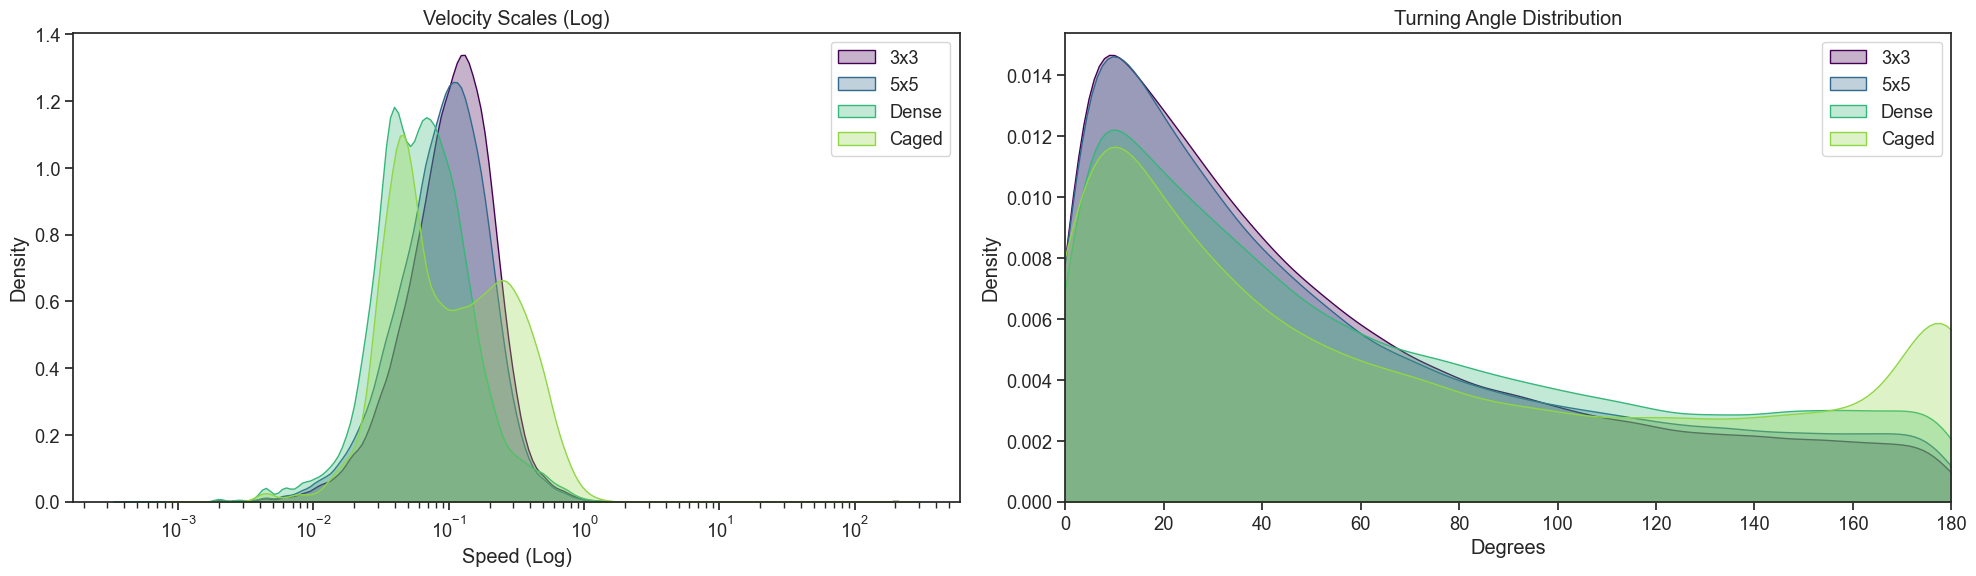

In [76]:
results = {
     '3x3': data_3x3,
     '5x5': data_5x5,
     'Dense': data_limit,
     'Caged': data_dense
}
plot_analysis(results)

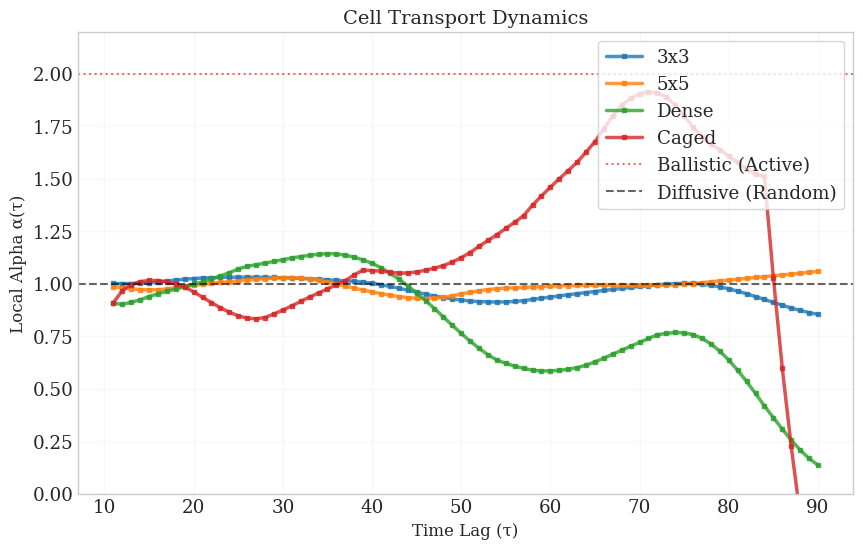

In [ ]:
def plot_local_alpha(results_dict, window=5):
    plt.figure(figsize=(10, 6))
    
    colors = {'3x3': '#1f77b4', '5x5': '#ff7f0e', 'Dense': '#2ca02c', 'Caged': '#d62728'}
    
    for label, df in results_dict.items():
        df_clean = df.dropna(subset=['centroid_x', 'centroid_y']).sort_values(['unique_id', 'timesteps'])
        
        all_msds = []
        for _, group in df_clean.groupby('unique_id'):
            if len(group) < 20: continue
            coords = group[['centroid_x', 'centroid_y']].values
            n = len(coords)
            res = np.zeros(n)
            for tau in range(1, n):
                diff = coords[tau:] - coords[:-tau]
                res[tau] = np.mean(np.sum(diff**2, axis=1))
            all_msds.append(res)
            
        if not all_msds: continue
        max_len = max(len(x) for x in all_msds)
        padded = np.array([np.pad(x, (0, max_len - len(x)), constant_values=np.nan) for x in all_msds])
        mean_msd = np.nanmean(padded, axis=0)
        tau = np.arange(len(mean_msd))
        mask = (tau > 0) & (mean_msd > 0)
        log_tau = np.log(tau[mask])
        log_msd = np.log(mean_msd[mask])
        local_alphas = []
        tau_centers = []
        
        for i in range(len(log_tau) - window):
            x_win = log_tau[i : i + window]
            y_win = log_msd[i : i + window]
            slope, _ = np.polyfit(x_win, y_win, 1)
            local_alphas.append(slope)
            tau_centers.append(tau[mask][i + window // 2])
        plt.plot(tau_centers[:80], local_alphas[:80], label=label, 
                 color=colors.get(label), lw=2.5, marker='s', markersize=3, alpha=0.8)

    plt.axhline(2, color='red', linestyle=':', alpha=0.6, label='Ballistic (Active)')
    plt.axhline(1, color='black', linestyle='--', alpha=0.6, label='Diffusive (Random)')
    
    plt.ylim(0, 2.2)
    plt.xlabel('Time Lag (τ)', fontsize=12)
    plt.ylabel('Local Alpha α(τ)', fontsize=12)
    plt.title('Cell Transport Dynamics', fontsize=14)
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, which="both", alpha=0.15)
    plt.show()

plot_local_alpha(results, window=20)